# Calculating ECCO Gent-McWilliams Bolus Velocity

*Contributor*: [Ou Wang](https://github.com/owang01)

## Objectives

Learn how to calculate ECCO Gent–McWilliams bolus velocities from the bolus streamfunction.

## Introduction

In ECCO, the Gent–McWilliams (GM) parameterization is provided in terms of bolus streamfunction components, here denoted `GM_PsiX` and `GM_PsiY`. These fields are defined on vertical interface levels (`k_l`). The corresponding bolus velocities are obtained by taking vertical differences of the streamfunction for the horizontal components and horizontal divergence of the streamfunction transport for the vertical component.

For the horizontal bolus velocities,
$$
u^\ast = \frac{\partial \Psi_x}{\partial z}, \qquad
v^\ast = \frac{\partial \Psi_y}{\partial z},
$$
where the discrete vertical derivative is evaluated from adjacent `k_l` levels and divided by the layer thickness `drF`. In practice, this means padding the streamfunction at the bottom, taking the difference between the upper and lower interfaces, and mapping the result from `k_l` to tracer levels `k`.

For the vertical bolus velocity,
$$
w^\ast = \frac{1}{A}\left[
\frac{\partial (\Psi_x \, \Delta y)}{\partial x}
+
\frac{\partial (\Psi_y \, \Delta x)}{\partial y}
\right],
$$
where $A$ is the horizontal cell area (`rA`), and $\Delta x$ and $\Delta y$ are the grid metrics (`dxG`, `dyG`). Thus, `bolusW` is computed from the horizontal divergence of the streamfunction transport.

In this notebook:
- `GM_PsiX` and `GM_PsiY` are first cleaned by replacing `NaN`s with zeros.
- `bolusU` and `bolusV` are computed from vertical differencing of `GM_PsiX` and `GM_PsiY`.
- `bolusW` is computed from the horizontal divergence of `GM_PsiX * dyG` and `GM_PsiY * dxG`.
- Grid masks are then applied so that the resulting velocities are defined only at valid wet grid points.

As a consistency check, the bolus flow should be nearly non-divergent, so the sum of horizontal and vertical convergence should be close to zero up to numerical error.

*The general structure of this notebook is adapted from an ECCO tutorial:  
[ECCO v4 Gradient calculation on native grid](https://github.com/ECCO-GROUP/ECCO-v4-Python-Tutorial/blob/master/Tutorials_as_Jupyter_Notebooks/ECCO_v4_Gradient_calc_on_native_grid.ipynb).*

## Preliminaries

This section sets up the environment and loads the ECCO grid and data needed for the analysis.

The following setup assumes that ECCO V4r4 grid and data are accessible locally. If not, refer to the ECCO V4 tutorials (see, e.g., [this example](https://github.com/ECCO-GROUP/ECCO-v4-Python-Tutorial/blob/master/Tutorials_as_Jupyter_Notebooks/ECCO_v4_Gradient_calc_on_native_grid.ipynb)) to access ECCO V4r4 data from the cloud.

### Prepare the working enviornment

In [1]:
import cartopy as cartopy
import cartopy.crs as ccrs
import glob
import importlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from pathlib import Path
import socket
from pprint import pprint
import sys
import xarray as xr
from os.path import join,expanduser
import xgcm as xgcm
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

import ecco_v4_py as ecco
# import ecco_access as ea

from ecco_v4_py import get_llc_grid as get_llc_grid
from ecco_v4_py import plot_proj_to_latlon_grid

### Set data root path based on host machine

In [2]:
host = socket.gethostname()

if host == "XYZ":
    data_root = Path("/ECCOV4r4/")
else:
    raise ValueError(f"Unknown machine: {host}")

### Load ECCO Geometry

First, load the llc model grid geometry.

In [3]:
## Load the model grid
ecco_grid = xr.open_dataset(data_root / 'grid/GRID_GEOMETRY_ECCO_V4r4_native_llc0090.nc')
ecco_grid = ecco_grid.compute()

### The logical connection between geographically adjacent tile edges

To calculate gradients for grid cells on the edges of model tiles we will need information from from logically adjacent tiles. For example, to calculate zonal gradients along the eastern edge of Tile 1 we need information found along the western edge of Tile 4 (i.e., we need to difference the field in the last column of Tile 1 and the first column of Tile 4) and gradients across the western edge of Tile 4 need information found along the eastern edge of Tile 8 (i.e., we need to difference the field in the last column of Tile 4 and the reversed first row of Tile 8). Managing these connections requires careful bookkeeping.  Fortunately the 'xgcm' Python library (https://xgcm.readthedocs.io/en/latest/) allows us to construct a logical map that specifies the logical relation between tiles. *So useful!*. 

To create the logical mapping for the ECCO llc grid we provide a helper routine, *get_llc_grid*: 

In [4]:
# Make the XGCM object
XGCM_grid = get_llc_grid(ecco_grid)

# look at the XGCM object.
print(XGCM_grid)

<xgcm.Grid>
Z Axis (not periodic, boundary='fill'):
  * center   k --> left
  * outer    k_p1 --> center
  * right    k_u --> center
  * left     k_l --> center
X Axis (not periodic, boundary='fill'):
  * center   i --> left
  * left     i_g --> center
Y Axis (not periodic, boundary='fill'):
  * center   j --> left
  * left     j_g --> center


Note: the **X** axis is defined by $i$ and $i_g$ grid indices while the  ***Y*** axis is defined by the $j$ and $j_g$ grid indices.

Now that we have the XGCM local grid object, the difference between adjacent rows or columns in tile arrays can be calculated using the xgcm *diff* subroutine. To convert local differences to gradients we specify the spacing between adjacent grid cells. The distances between adjacent grid cell *centers* are contained in the $dxC$ and $dyC$ fields of the ECCO grid dataset, respectively.

See https://xgcm.readthedocs.io/en/latest/api.html#xgcm.Grid.diff for more details about the 'diff' function

Now that we have been introduced to the $SN$ and $CS$ rotation factors and the **XGCM_grid** object we can proceed!

## GM Bolus Velocity Calculation

### Load the model Gent-McWilliams Bolus Streamfunction

In [5]:
# Load monthly bolus streamfunction from 2010
dir0=data_root / 'native/mon_mean/'
ecco_vars = xr.open_mfdataset(str(dir0 / 'OCEAN_BOLUS_STREAMFUNCTION/OCEAN_BOLUS_STREAMFUNCTION_mon_mean_2010-??_ECCO_V4r4_native_llc0090.nc'))

### Cast GM_PsiX and GM_PsiY to float64 for better precision

In [6]:
ecco_vars["GM_PsiX"] = ecco_vars["GM_PsiX"].astype("float64")
ecco_vars["GM_PsiY"] = ecco_vars["GM_PsiY"].astype("float64")

### Merge ECCO grid and variables and inspect dataset

In [7]:
ecco_ds = xr.merge((ecco_grid , ecco_vars)).compute()

# inspect dataset
print(list(ecco_vars.data_vars))

['GM_PsiX', 'GM_PsiY']


In [8]:
ecco_vars['GM_PsiX']

<xarray.DataArray 'GM_PsiX' (time: 12, k_l: 50, tile: 13, j: 90, i_g: 90)> Size: 505MB
dask.array<astype, shape=(12, 50, 13, 90, 90), dtype=float64, chunksize=(1, 25, 7, 45, 45), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 96B 2010-01-16T12:00:00 ... 2010-12-16T12:...
  * k_l      (k_l) int32 200B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
    Zl       (k_l) float32 200B dask.array<chunksize=(50,), meta=np.ndarray>
  * tile     (tile) int32 52B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * j        (j) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * i_g      (i_g) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
Attributes:
    long_name:              Gent-Mcwilliams bolus transport streamfunction in...
    units:                  m2 s-1
    mate:                   GM_PsiY
    coverage_content_type:  modelResult
    comment:                Gent-Mcwilliams bolus transport streamfunction 'u...
    valid_min:              -4.762289524078369
    valid_max:              4.927858352661133

### Extract GM streamfunction components (GM_PsiX, GM_PsiY)

In [9]:
GM_PsiX = ecco_ds['GM_PsiX']
GM_PsiY = ecco_ds['GM_PsiY']

### Compute GM bolus velocities (bolusU, bolusV, bolusW) from streamfunction

Prepare auxiliary fields on k_l levels, handle missing values, and compute bolus velocities (bolusU, bolusV, bolusW) from GM streamfunction components using vertical differencing and horizontal divergence.

#### Prepare auxiliary fields and clean GM streamfunction inputs

In [10]:
# --------------------------------------------------
# 0. Auxiliary fields on k_l
# --------------------------------------------------
maskC_on_kl = ecco_ds.maskC.rename({"k": "k_l"}).assign_coords(k_l=GM_PsiX.k_l)
drF_on_kl   = ecco_ds.drF.rename({"k": "k_l"}).assign_coords(k_l=GM_PsiX.k_l)

# --------------------------------------------------
# 1. Replace NaNs with 0
# --------------------------------------------------
GM_PsiX0 = GM_PsiX.fillna(0)
GM_PsiY0 = GM_PsiY.fillna(0)

#### Define helper function to compute bolusU and bolusV

In [11]:
# --------------------------------------------------
# 2. Helper for bolusU / bolusV
# --------------------------------------------------
def psi_to_bolus_uv(psi):
    psi_pad = xr.concat(
        [
            psi,
            xr.zeros_like(psi.isel(k_l=-1)).expand_dims(k_l=[psi.sizes["k_l"]]),
        ],
        dim="k_l",
    )

    upper = psi_pad.isel(k_l=slice(1, None)).assign_coords(k_l=psi.k_l)
    lower = psi_pad.isel(k_l=slice(0, -1)).assign_coords(k_l=psi.k_l)

    out = ((upper - lower) / drF_on_kl).rename({"k_l": "k"})
    return out.assign_coords(k=ecco_ds.k)

#### Compute horizontal GM bolus velocities (bolusU, bolusV)

In [12]:
# --------------------------------------------------
# 3. Compute bolusU and bolusV
# --------------------------------------------------
bolusU = psi_to_bolus_uv(GM_PsiX0).where(ecco_ds.maskW, 0)
bolusV = psi_to_bolus_uv(GM_PsiY0).where(ecco_ds.maskS, 0)

bolusU.name = "bolusU"
bolusV.name = "bolusV"

#### Compute vertical GM bolus velocity (bolusW)

In [13]:
# --------------------------------------------------
# 4. Compute bolusW on k_l
# --------------------------------------------------
tmp_x = GM_PsiX0 * ecco_ds.dyG
tmp_y = GM_PsiY0 * ecco_ds.dxG

div = XGCM_grid.diff_2d_vector(
    {"X": tmp_x, "Y": tmp_y},
    boundary="fill",
    fill_value=0,
)

bolusW = ((div["X"] + div["Y"]) / ecco_ds.rA).where(maskC_on_kl, 0)
bolusW.name = "bolusW"

#### Construct transports and compute convergence (non-divergence check)

Compute volume transports from bolus velocities and evaluate horizontal and vertical convergence terms.

- **hConv**: horizontal convergence, computed as the negative divergence of horizontal transports  
- **vConv**: vertical convergence, computed from the vertical derivative of vertical transport  
- **Conv = hConv + vConv**: total convergence, which should be close to zero if the bolus velocity field is non-divergent

In [14]:
# --------------------------------------------------
# 4. Non-divergence check
#    div_x + div_y + div_z should be close to 0 on k
# --------------------------------------------------

u_trans = bolusU * ecco_ds.dyG * ecco_ds.drF
v_trans = bolusV * ecco_ds.dxG * ecco_ds.drF
w_trans = bolusW * ecco_ds.rA

xy_vec_diff = XGCM_grid.diff_2d_vector(
    {"X": u_trans, "Y": v_trans}, boundary="fill", fill_value=0.0
)
x_diff = xy_vec_diff["X"]
y_diff = xy_vec_diff["Y"]
hConv = -(x_diff + y_diff)

# w_trans is on k_l, so diff in Z to center gives result on k
vConv = XGCM_grid.diff(
    w_trans,
    "Z",
    to="center",
    boundary="fill",
    fill_value=0,
)

Conv =  hConv + vConv
Conv = Conv.where(ecco_ds.maskC != 0)

# # Conv per unit volume (in 1/s)
# cell_vol = ecco_ds.rA * ecco_ds.drF
# if "hFacC" in ecco_ds:
#     cell_vol = cell_vol * ecco_ds.hFacC

# Conv_vol = xr.where(cell_vol != 0, div_total / cell_vol, np.nan)
# Conv_vol = Conv_vol.where(ecco_ds.maskC != 0)

#### Diagnose non-divergence error statistics

Report maximum and mean absolute values of horizontal, vertical, and total convergence to assess how close the solution is to non-divergent.

In [15]:
UNIT = "m3 s-1"

max_h = np.nanmax(np.abs(hConv))
mean_h = np.nanmean(np.abs(hConv))

max_v = np.nanmax(np.abs(vConv))
mean_v = np.nanmean(np.abs(vConv))

max_c = np.nanmax(np.abs(Conv))
mean_c = np.nanmean(np.abs(Conv))

print(f"{'max  abs(hConv)':<25} = {max_h:.6e} {UNIT}")
print(f"{'mean abs(hConv)':<25} = {mean_h:.6e} {UNIT}")
print(f"{'max  abs(vConv)':<25} = {max_v:.6e} {UNIT}")
print(f"{'mean abs(vConv)':<25} = {mean_v:.6e} {UNIT}")
print(f"{'max  abs(Conv)':<25} = {max_c:.6e} {UNIT}")
print(f"{'mean abs(Conv)':<25} = {mean_c:.6e} {UNIT}")

threshold = 1e-5

r_max_h = max_c / max_h
r_max_v = max_c / max_v
r_mean_h = mean_c / mean_h
r_mean_v = mean_c / mean_v

print("\n--- Non-divergence check ---")
print(f"Ratio (max |Conv| / max |hConv|): {r_max_h:.3e}")
print(f"Ratio (max |Conv| / max |vConv|): {r_max_v:.3e}")
print(f"Ratio (mean|Conv| / mean|hConv|): {r_mean_h:.3e}")
print(f"Ratio (mean|Conv| / mean|vConv|): {r_mean_v:.3e}")

print("\nInterpretation:")
print(f"A ratio smaller than {threshold:.0e} indicates good numerical consistency.")

if all(r < threshold for r in [r_max_h, r_max_v, r_mean_h, r_mean_v]):
    print("✅ The bolus velocity field is effectively non-divergent.")
else:
    print("⚠️ Residual divergence is larger than expected; check calculations or masking.")

max  abs(hConv)           = 6.001827e+05 m3 s-1
mean abs(hConv)           = 2.211399e+03 m3 s-1
max  abs(vConv)           = 6.001827e+05 m3 s-1
mean abs(vConv)           = 2.211399e+03 m3 s-1
max  abs(Conv)            = 1.182343e-10 m3 s-1
mean abs(Conv)            = 8.134502e-13 m3 s-1

--- Non-divergence check ---
Ratio (max |Conv| / max |hConv|): 1.970e-16
Ratio (max |Conv| / max |vConv|): 1.970e-16
Ratio (mean|Conv| / mean|hConv|): 3.678e-16
Ratio (mean|Conv| / mean|vConv|): 3.678e-16

Interpretation:
A ratio smaller than 1e-05 indicates good numerical consistency.
✅ The bolus velocity field is effectively non-divergent.


#### Plot horizontal, vertical, and total convergence

Plot `hConv`, `vConv`, and `Conv` at a selected time and vertical level to visually verify that the total convergence is much smaller than the horizontal and vertical components.

These maps complement the scalar diagnostics above. While `hConv` and `vConv` can each have substantial magnitude, they should largely cancel, leaving `Conv = hConv + vConv` much smaller if the bolus velocity field is close to non-divergent.

##### Prepare fields and plotting parameters for selected time and depth

Select a time index and vertical level, extract the corresponding fields, and compute/set common and zoomed color scales for plotting convergence terms.

In [16]:
itime = 0
k = 4
UNIT_TRANSPORT = r"$\mathrm{m^3\,s^{-1}}$"

# Extract time label (YYYY-MM)
time_str = np.datetime_as_string(ecco_ds.time.values[itime], unit="M")

# Extract depth (in meters)
depth = float(ecco_ds.Z.values[k])  # typically negative
depth_str = f"{abs(depth):.0f} m"

# Precompute (important for speed)
h0 = hConv.isel(time=itime, k=k)#.compute()
v0 = vConv.isel(time=itime, k=k)#.compute()
c0 = Conv.isel(time=itime, k=k)#.compute()

lons = ecco_ds.XC.values
lats = ecco_ds.YC.values

# Common color scale
cmax_common = 0.2*np.nanmax([
    np.nanmax(np.abs(h0.values)),
    np.nanmax(np.abs(v0.values)),
    np.nanmax(np.abs(c0.values)),
])
cmin_common = -cmax_common

# Zoomed scale for Conv
cmax_conv = 0.2*np.nanmax(np.abs(c0.values))
cmin_conv = -cmax_conv

#### Plot convergence terms (hConv, vConv, Conv)

Plot horizontal and vertical convergence (`hConv`, `vConv`) and their sum (`Conv`) at a selected time and depth. The first three panels use a common color scale to show that `Conv` is much smaller than its components, while the fourth panel uses a tighter color scale to reveal the spatial structure of `Conv`.

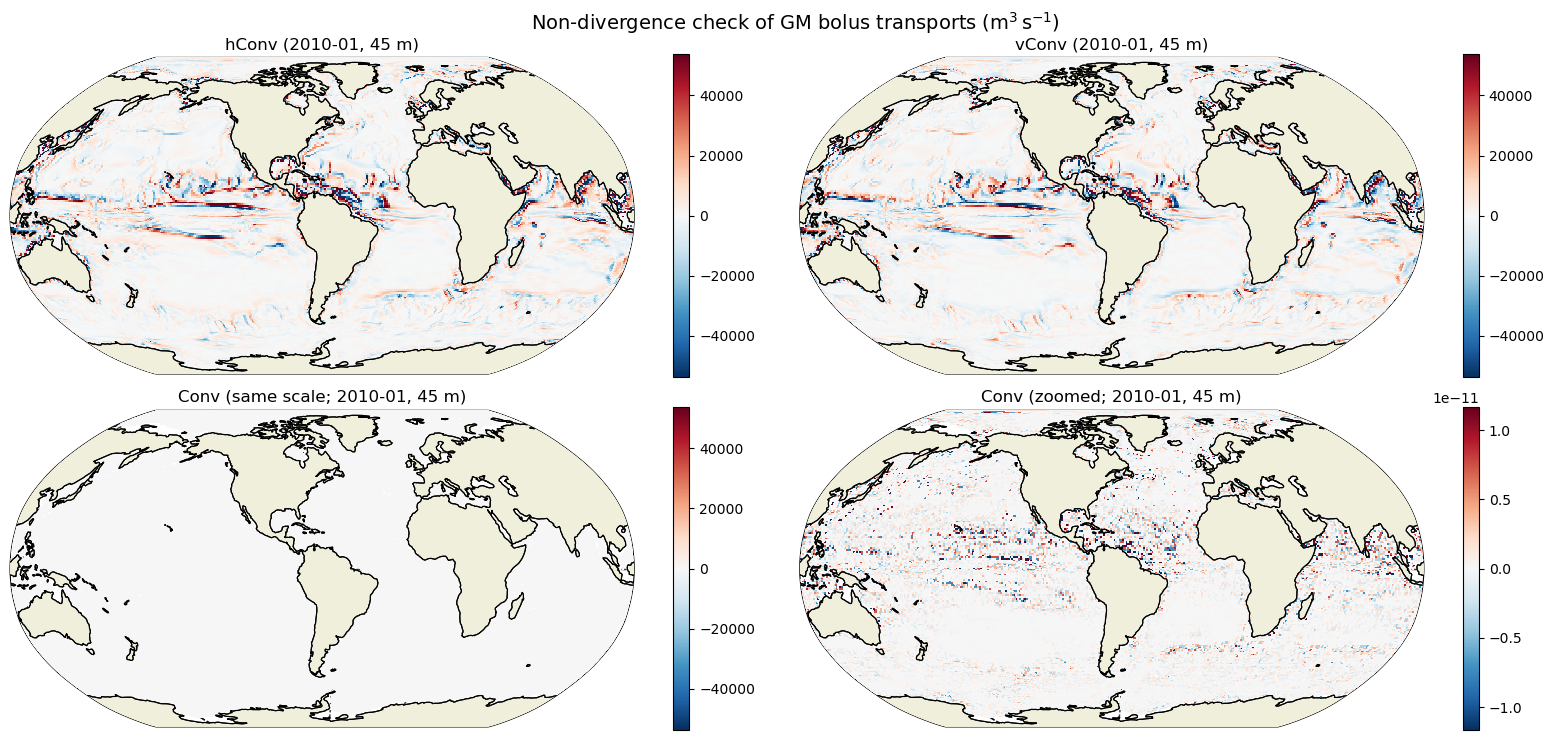

In [17]:
plt.figure(figsize=(16, 7.5))

# --- hConv ---
fig0=plot_proj_to_latlon_grid(
    lons, lats, h0.values,
    subplot_grid=[2, 2, 1],
    user_lon_0=-67,
    cmin=cmin_common, cmax=cmax_common,
    show_colorbar=True,
    show_grid_labels=False,
    less_output=True
)
fig0[1].set_title(f"hConv ({time_str}, {depth_str})")

# --- vConv ---
fig1=plot_proj_to_latlon_grid(
    lons, lats, v0.values,
    subplot_grid=[2, 2, 2],
    user_lon_0=-67,
    cmin=cmin_common, cmax=cmax_common,
    show_colorbar=True,
    show_grid_labels=False,
    less_output=True
)
fig1[1].set_title(f"vConv ({time_str}, {depth_str})")

# --- Conv (same scale) ---
fig2=plot_proj_to_latlon_grid(
    lons, lats, c0.values,
    subplot_grid=[2, 2, 3],
    user_lon_0=-67,
    cmin=cmin_common, cmax=cmax_common,
    show_colorbar=True,
    show_grid_labels=False,
    less_output=True
)
fig2[1].set_title(f"Conv (same scale; {time_str}, {depth_str})")

# --- Conv (zoomed) ---
fig3=plot_proj_to_latlon_grid(
    lons, lats, c0.values,
    subplot_grid=[2, 2, 4],
    user_lon_0=-67,
    cmin=cmin_conv, cmax=cmax_conv,
    show_colorbar=True,
    show_grid_labels=False,
    less_output=True
)
fig3[1].set_title(f"Conv (zoomed; {time_str}, {depth_str})")

plt.suptitle(f"Non-divergence check of GM bolus transports ({UNIT_TRANSPORT})", fontsize=14)

plt.tight_layout()
plt.show()